# Get resulte on tng and flamingo

In [1]:
%load_ext autoreload
%autoreload 2

Loop through each filter and all the models and determine the threshold values for each

In [2]:
from get_model_probabilities import *
from add_shear_to_data import *
import scienceplots
plt.style.use(["science","grid"])

DEFAULT ZS 2.28808070104492
Source redshift:2.2884950162268827


In [8]:
imonte=5

#target_test_acc = pkl.load(open("pickles/target_test_accuracy.pkl","rb"))

ifilter='concat'
all_models, seed_index =  get_model_names(model='tweakedalign_final') 


output_name = f"pickles/vdsidm_results.pkl"

all_results = {} #pkl.load(open(output_name,'rb'))

obs_data = get_obs_data(ifilter, data_dir="../data/100/a2744/", photoz=True)

delta_ra, delta_dec = ra_dec_to_simulation_image_pos( obs_data )

n_z = get_variable_redshift_dist()

args.zs = n_z

for imodel in tqdm(all_models):

    seed = imodel.split('_')[seed_index]

    args.jwst_filter = ifilter
    args.apply_intrinsic_ell = 1.
    args.verbose=False

    all_domains = {
        'vd_bahamas':'../data/100/obs/concat/vd_bahamas.pkl',
        'vd_ds_20_200':'../data/100/obs/concat/vd_darkskies_20_200.pkl',
        'vd_ds_70_130':'../data/100/obs/concat/vd_darkskies_70_130.pkl',
        'vd_ds_70_50':'../data/100/obs/concat/vd_darkskies_70_50.pkl'
    }    
    all_domains = {
        'vd_bahamas':'../data/100/obs/concat/vd_bahamas.pkl'
    }
    args.ignore_dataset = [''] # Although i ignored during training i want to see duringn testing.

    if f"seed_{seed}" not in all_results.keys():

        all_results[f"seed_{seed}"]  = {}

    args.unbalance = True
    
    for i in range(imonte):
        

        for domain_name, idomain in all_domains.items():
            
            if domain_name not in all_results[f"seed_{seed}"].keys():
                all_results[f"seed_{seed}"][domain_name] = []

            results = get_probabilities( 
                    idomain,
                    [imodel],
                    args,
                    quiet=True
            )
            del results['data_loaders']

            all_results[f"seed_{seed}"][domain_name].append( results )

    pkl.dump(all_results, open(output_name,"wb"))


DEFAULT ZS 2.28808070104492
DEFAULT ZS 2.28808070104492


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [38:40<00:00, 77.33s/it]


In [25]:

ifilter  = 'concat'



this_domain = [ {
    'tgt':'darkskiesvd_vd',
    'src':'bahamasvd_vd'
    },
    {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
    }]

fiducial = f"pickles/all_models_concat_nz_alignbest_results.pkl"
vdsidm = f"pickles/vdsidm_results.pkl"

colors = {'vd_20_200':'pink','vd_70_130':'HotPink','vd_ds_20_200':'purple',
    'flamingo':'cyan', 'src':'r', 'tgt':'b','tng':'green',
        'vd_bahamas':'orange','darkskiesvd':'purple'}


domain = this_domain[0]

all_results = pkl.load(open(vdsidm,'rb'))

postive_mass, mass_cut = get_mass_cut( ifilter, nsigma=2., study='harvey' )

plot_results = {}

for itgt, target in enumerate(all_results['seed_1'].keys()):
    all_thresholds = []

    for imodel in all_results.keys():

        seed = float(imodel.split('_')[1])                
        mass_weights = get_massfunction_weights(
                target
            )

        tgt = get_threshold_for_cross( 
            all_results[imodel][target], 
            function=np.mean,
            mass_cut=mass_cut,
            integrated_mass=True,
            mass_weights=mass_weights,
            dataset=target,
            ncomponents=1,
            quiet=False)


        all_thresholds.append(tgt['thresholds'])

    all_thresholds = np.array(all_thresholds)
    means = np.nanmean(all_thresholds,axis=0)
    errors = return_error_in_mean( all_thresholds)

    plot_results[target] = [ tgt['cross_sections'], means, errors ] 

domain = this_domain[1]

all_results = pkl.load(open(fiducial,'rb'))

for itgt, target in enumerate(['src','tgt']):
    all_thresholds = []

    for imodel in all_results.keys():

        seed = float(imodel.split('_')[1])                


        tgt = get_threshold_for_cross( 
            all_results[imodel][target], 
            function=np.mean,
            mass_cut=mass_cut,
            integrated_mass=True,
            mass_weights=mass_weights,
            dataset=this_domain[1][target].split('_')[0],
            ncomponents=1,
            quiet=False)


        all_thresholds.append(tgt['thresholds'])

    all_thresholds = np.array(all_thresholds)
    means = np.nanmean(all_thresholds,axis=0)
    errors = return_error_in_mean( all_thresholds )
    plot_results[this_domain[1][target].split('_')[0]] = [ tgt['cross_sections'], means, errors ] 

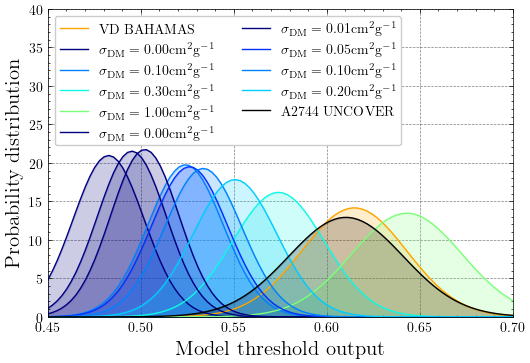

In [37]:
config='baha2dark'

ifilter  = 'concat'
cdm = 3e-3

color = {
        'src':'r',
        'tgt':'b'
    }




model = f"pickles/{config}_basemodel_results.pkl"

all_results = pkl.load(open(model,'rb'))


fig = plt.figure(figsize=(6,4))

ax = plt.gca()


this_domain = [ {
    'tgt':'darkskiesvd_vd',
    'src':'bahamasvd_vd'
    },
    {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
    }]

fiducial = f"pickles/all_models_concat_nz_results.pkl"
vdsidm = f"pickles/vdsidm_results.pkl"

colors = {'vd_20_200':'pink','vd_70_130':'HotPink','vd_ds_20_200':'purple',
    'flamingo':'cyan', 'src':'r', 'tgt':'b','tng':'green',
        'vd_bahamas':'orange','darkskiesvd':'purple'}


domain = this_domain[0]


all_results = pkl.load(open(vdsidm,'rb'))

postive_mass, mass_cut = get_mass_cut( ifilter, nsigma=2., study='harvey' )


mass_cut = [ i for i in mass_cut]

ref = None


for itgt, target in enumerate(all_results['seed_1'].keys()):
    cross, means, errors = plot_results[target]

    xpdf = np.linspace(0.45,0.7, 100)

    ypdf = norm.pdf( xpdf, *(1-means[0], errors[0]))

    ax.plot(  xpdf, ypdf,
                    label=target.replace('_',' ').upper(),
                     color=colors[f"{target.lower()}"]
           )

    ax.fill_between( xpdf,
                    ypdf,
                    np.zeros(100),
                     color=colors[f"{target.lower()}"],
                   alpha=0.2)
    break
domain = this_domain[1]

all_results = pkl.load(open(fiducial,'rb'))

sidm_colors = colourFromRange([-2,2,], cmap='jet')
for itgt, target in enumerate(['src','tgt']):
    all_thresholds = []

    cross, means, errors = plot_results[this_domain[1][target].split('_')[0]]


    for  imean in range(means.shape[0]):
        xpdf = np.linspace(0.45,0.7, 100)

        ypdf = norm.pdf( xpdf, *(1-means[imean], errors[imean]))

        ax.plot(  xpdf, ypdf,
                        label=f"$\sigma_{{\\rm DM}}={cross[imean]:0.2f}$cm$^2$g$^{{-1}}$",
                         color=sidm_colors[np.log10(cross[imean])]
               )

        ax.fill_between( xpdf,
                        ypdf,
                        np.zeros(100),
                         color=sidm_colors[np.log10(cross[imean])],
                       alpha=0.2)
        
        
ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")

ax.set_xlabel("Model threshold output", fontsize=15)

ax.set_ylabel("Probability distribution", fontsize=15)

ax.set_ylim(0,ax.get_ylim()[1])
ax.set_xlim(xpdf.min(), xpdf.max())

models, probabilities, probabilities_noise = pkl.load(open("pickles/model_on_data.pkl",'rb'))
data = probabilities[ifilter]
nmodels = data.shape[0]



means = 1-np.mean(data)
error = return_error_in_mean( data )

ypdf = norm.pdf( xpdf, *(means, error))

ax.plot(  xpdf, ypdf,
                    label='A2744 UNCOVER',
                     color='k')

ax.fill_between( xpdf,
                    ypdf,
                    np.zeros(100),
                     color='k',
                   alpha=0.2)  
ax.set_ylim(0,40)
ax.legend(ncols=2,loc=2)
